In [1]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm

In [2]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

       country  year  incidence           gdp       bmi    pop_65  urban_pop  \
0         chad  1990  11.784239   1705.042265  0.038681  3.455495     20.811   
1        india  1990   8.650421   2203.147039  0.014403  4.037870     25.547   
2  puerto rico  1990  51.408888           NaN  0.044402       NaN        NaN   
3         oman  1990   5.197615  35201.552487  0.052449  2.453040     66.102   
4       zambia  1990  14.798816   2425.111287  0.110025  2.880287     39.407   

   life_exp  fertility  labor_rate  
0    48.799      7.219      64.570  
1    59.358      4.045      30.225  
2       NaN        NaN         NaN  
3    71.752      6.456      22.489  
4    49.410      6.567      51.414  


# OECD  Countries :

In [3]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'columbia', 'czech republic', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovak republic', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkey', 'united kingdom', 'united states']

# Creat Dummy Variables:

In [4]:
#final_df['is_oecd'] = final_df['country'].isin(oecd_list).astype(int)
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# creat interaction :

is_oecd
0    5882
1    1054
Name: count, dtype: int64


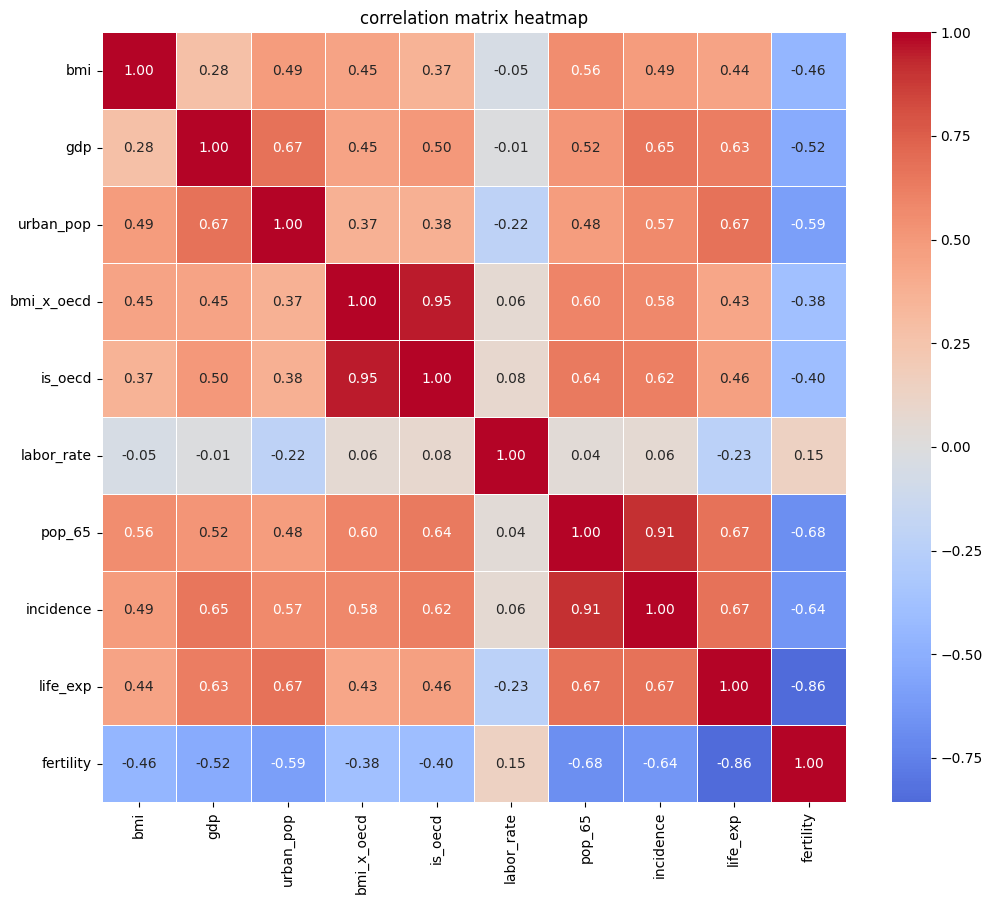

In [5]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())
columns_for_heatmap=['bmi', 'gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate', 'pop_65'
                      ,'incidence', 'life_exp', 'fertility']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()